# $\bar{n}$ sweep with variable decoherence rates

$\bar{n}$ に対する MS gate の average infidelity を、4つのノイズ強度を変えながら比較。各パネルでは対象のノイズだけを変化させ、他の3ノイズは基準値に固定します。

- Motional heating: $\dot{\bar{n}}$ [$\mathrm{s}^{-1}$]
- Motional dephasing: $\gamma_m$ [$\mathrm{s}^{-1}$]
- Spin dephasing: $\gamma_s=1/T_2^*$ [$\mathrm{s}^{-1}$]
- Photon scattering: $\gamma_{sc}=\gamma_{Rayleigh}+\gamma_{Raman}$ [$\mathrm{s}^{-1}$]

Photon scattering の Rayleigh:Raman 比は基準値の 3:1 に保ちます。各曲線の凡例には、倍率ではなく実際にシミュレータに渡した物理レートを表示します。

## 1. Configuration

`RATE_MULTIPLIERS` を変えると、各ノイズの基準値に対する曲線を増減できます。Full QPT は重いため、設定確認後に `EXECUTE_QPT=True` にして実行してください。

In [7]:
from pathlib import Path
import importlib
import json
import os

# Avoid nested BLAS/OpenMP parallelism inside each QPT worker.
# Run this cell before importing NumPy/QuTiP for the setting to take effect.
for thread_env in (
    'OMP_NUM_THREADS',
    'OPENBLAS_NUM_THREADS',
    'MKL_NUM_THREADS',
    'VECLIB_MAXIMUM_THREADS',
    'NUMEXPR_NUM_THREADS',
):
    os.environ[thread_env] = '1'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

import ms_gate_functions as mg
mg = importlib.reload(mg)

# Horizontal-axis values.  Increase the density only after a short test run.
NBAR_VALUES = (0.01, 1.0, 2.0, 3.0, 4.0)

# Each panel uses these multiples of its nominal physical rate.
RATE_MULTIPLIERS = (0.0, 0.5, 1.0, 2.0, 4.0)
NOISE_SOURCES = (
    'motional_heating',
    'motional_dephasing',
    'spin_dephasing',
    'photon_scattering',
)

EXECUTE_QPT = True  # Set True to calculate missing conditions.
RESUME = True        # Reuse complete conditions from summary.csv.
OUTPUT_DIR = Path('results/noise_rate_nbar_sweep')

# Number of parallel QPT workers. Change only this value as needed.
WORKERS = 16
CPU_COUNT = os.cpu_count() or 1
if not isinstance(WORKERS, int) or WORKERS < 1:
    raise ValueError('WORKERS must be a positive integer.')
if WORKERS > CPU_COUNT:
    print(f'Warning: WORKERS={WORKERS} exceeds the detected CPU count ({CPU_COUNT}).')
print(f'CPU count: {CPU_COUNT}; QPT parallel workers: {WORKERS}')

# Same baseline as main.ipynb. All rates below are in physical time.
BASE_PARAMETERS = {
    'A': 0.125,
    'delta': 0.5,
    'rho0': 0.0,
    'n_bar_list': list(NBAR_VALUES),
    'time_points': 500,
    't_gate_phys': 100e-6,
    'heating_rate_phys': 10.0,
    'dephasing_rate_phys': 18.0,
    'T2_star': 0.3,
    'rayleigh_rate_phys': 3.0,
    'raman_rate_phys': 1.0,
    'eta': 0.1,
    'laser_intensity_fluctuation': 0.0,
    'laser_detuning_fluctuation': 0.0,
    'laser_rotation_angle_fluctuation': 0.0,
    'laser_noise_samples': 1,
    'laser_noise_seed': 1234,
    'use_full_order': True,
    'show_progress': True,
    'parallel_workers': WORKERS,
}
BASE_PARAMETERS

CPU count: 48; QPT parallel workers: 16


{'A': 0.125,
 'delta': 0.5,
 'rho0': 0.0,
 'n_bar_list': [0.01, 1.0, 2.0, 3.0, 4.0],
 'time_points': 500,
 't_gate_phys': 0.0001,
 'heating_rate_phys': 10.0,
 'dephasing_rate_phys': 18.0,
 'T2_star': 0.3,
 'rayleigh_rate_phys': 3.0,
 'raman_rate_phys': 1.0,
 'eta': 0.1,
 'laser_intensity_fluctuation': 0.0,
 'laser_detuning_fluctuation': 0.0,
 'laser_rotation_angle_fluctuation': 0.0,
 'laser_noise_samples': 1,
 'laser_noise_seed': 1234,
 'use_full_order': True,
 'show_progress': True,
 'parallel_workers': 16}

## 2. Build the rate scenarios

Spin dephasing はスイープ値 $\gamma_s$ を `T2_star = 1/gamma_s` に変換します。$\gamma_s=0$ のときは `T2_star = inf` です。

In [2]:
SOURCE_TITLES = {
    'motional_heating': 'Motional heating',
    'motional_dephasing': 'Motional dephasing',
    'spin_dephasing': 'Spin dephasing',
    'photon_scattering': 'Photon scattering',
}
SOURCE_SYMBOLS = {
    'motional_heating': r'$\dot{\bar{n}}$',
    'motional_dephasing': r'$\gamma_m$',
    'spin_dephasing': r'$\gamma_s$',
    'photon_scattering': r'$\gamma_{sc}$',
}

NOMINAL_STRENGTHS = mg.nominal_noise_source_strengths(BASE_PARAMETERS)
RATE_VALUES = {
    source: tuple(float(multiplier * NOMINAL_STRENGTHS[source]) for multiplier in RATE_MULTIPLIERS)
    for source in NOISE_SOURCES
}

def parameters_with_varied_rate(base_parameters, source, strength):
    """Vary one physical noise rate while keeping all other rates nominal."""
    if source not in NOISE_SOURCES:
        raise ValueError(f'Unknown source: {source}')
    strength = float(strength)
    if not np.isfinite(strength) or strength < 0.0:
        raise ValueError('Noise strength must be finite and non-negative.')

    parameters = dict(base_parameters)
    parameters['n_bar_list'] = list(NBAR_VALUES)
    if source == 'motional_heating':
        parameters['heating_rate_phys'] = strength
    elif source == 'motional_dephasing':
        parameters['dephasing_rate_phys'] = strength
    elif source == 'spin_dephasing':
        parameters['T2_star'] = np.inf if strength == 0.0 else 1.0 / strength
    elif source == 'photon_scattering':
        rayleigh_nominal = float(base_parameters['rayleigh_rate_phys'])
        raman_nominal = float(base_parameters['raman_rate_phys'])
        scattering_nominal = rayleigh_nominal + raman_nominal
        rayleigh_fraction = 0.75 if scattering_nominal == 0.0 else rayleigh_nominal / scattering_nominal
        parameters['rayleigh_rate_phys'] = strength * rayleigh_fraction
        parameters['raman_rate_phys'] = strength * (1.0 - rayleigh_fraction)
    return parameters

def legend_label(source, strength):
    return f"{SOURCE_SYMBOLS[source]} = {float(strength):g} " + r'$\mathrm{s}^{-1}$'

scenario_rows = []
for source in NOISE_SOURCES:
    for multiplier, strength in zip(RATE_MULTIPLIERS, RATE_VALUES[source]):
        parameters = parameters_with_varied_rate(BASE_PARAMETERS, source, strength)
        scenario_rows.append({
            'noise_source': source,
            'multiplier': multiplier,
            'varied_strength_s^-1': strength,
            'heating_s^-1': parameters['heating_rate_phys'],
            'motional_dephasing_s^-1': parameters['dephasing_rate_phys'],
            'spin_dephasing_s^-1': 0.0 if np.isinf(parameters['T2_star']) else 1.0 / parameters['T2_star'],
            'photon_scattering_s^-1': parameters['rayleigh_rate_phys'] + parameters['raman_rate_phys'],
        })
SCENARIOS = pd.DataFrame(scenario_rows)
display(SCENARIOS)

,noise_source,multiplier,varied_strength_s^-1,heating_s^-1,motional_dephasing_s^-1,spin_dephasing_s^-1,photon_scattering_s^-1
0,motional_heating,0.0,0.000000,0.0,18.0,3.333333,4.0
1,motional_heating,0.5,5.000000,5.0,18.0,3.333333,4.0
2,motional_heating,1.0,10.000000,10.0,18.0,3.333333,4.0
3,motional_heating,2.0,20.000000,20.0,18.0,3.333333,4.0
4,motional_heating,4.0,40.000000,40.0,18.0,3.333333,4.0
5,motional_dephasing,0.0,0.000000,10.0,0.0,3.333333,4.0
6,motional_dephasing,0.5,9.000000,10.0,9.0,3.333333,4.0
7,motional_dephasing,1.0,18.000000,10.0,18.0,3.333333,4.0
8,motional_dephasing,2.0,36.000000,10.0,36.0,3.333333,4.0
9,motional_dephasing,4.0,72.000000,10.0,72.0,3.333333,4.0


## 3. Run or resume the full-QPT sweep

1条件で `len(NBAR_VALUES) x 16` 回の time evolution を行います。既定設定は 4ノイズ $\times$ 5強度 $\times$ 5温度です。各ノイズの各強度が完了するたびに `summary.csv` へ保存するため、中断後は `RESUME=True` で再開できます。

In [4]:
SUMMARY_PATH = OUTPUT_DIR / 'summary.csv'
CONFIG_PATH = OUTPUT_DIR / 'config.json'

def _jsonable(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {str(key): _jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [_jsonable(item) for item in value]
    if isinstance(value, float) and not np.isfinite(value):
        return str(value)
    return value

RUN_CONFIG = _jsonable({
    'nbar_values': NBAR_VALUES,
    'rate_multipliers': RATE_MULTIPLIERS,
    'noise_sources': NOISE_SOURCES,
    'base_parameters': BASE_PARAMETERS,
})

# These settings change execution behavior only, not the physical result.
RUNTIME_ONLY_PARAMETER_KEYS = {'parallel_workers', 'show_progress'}

def scientific_config(config):
    comparable = json.loads(json.dumps(config))
    base_parameters = comparable.get('base_parameters', {})
    for key in RUNTIME_ONLY_PARAMETER_KEYS:
        base_parameters.pop(key, None)
    return comparable

if RESUME and CONFIG_PATH.exists():
    saved_config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
    if scientific_config(saved_config) != scientific_config(RUN_CONFIG):
        raise RuntimeError(
            'Saved physical configuration differs from the current settings. '
            'Use a new OUTPUT_DIR, or set RESUME=False to start a new summary.'
        )
    if saved_config != RUN_CONFIG:
        print('Runtime-only settings changed; cached physical results remain reusable.')

if RESUME and SUMMARY_PATH.exists():
    summary = pd.read_csv(SUMMARY_PATH)
else:
    summary = pd.DataFrame()

def condition_is_complete(table, source, strength):
    if table.empty:
        return False
    mask = (table['noise_source'] == source) & np.isclose(table['varied_strength_s^-1'], strength)
    completed_nbars = np.sort(table.loc[mask, 'nbar'].astype(float).unique())
    return len(completed_nbars) == len(NBAR_VALUES) and np.allclose(completed_nbars, np.sort(NBAR_VALUES))

if EXECUTE_QPT:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    CONFIG_PATH.write_text(json.dumps(RUN_CONFIG, indent=2, sort_keys=True), encoding='utf-8')

    for source in NOISE_SOURCES:
        for multiplier, strength in zip(RATE_MULTIPLIERS, RATE_VALUES[source]):
            if RESUME and condition_is_complete(summary, source, strength):
                print(f'Skip complete condition: {source}, strength={strength:g} s^-1')
                continue

            print(f'Run: {source}, strength={strength:g} s^-1 ({multiplier:g} x nominal)')
            parameters = parameters_with_varied_rate(BASE_PARAMETERS, source, strength)
            result = mg.run_infidelity_analysis(show_plot=False, **parameters)
            rows = pd.DataFrame({
                'noise_source': source,
                'multiplier': float(multiplier),
                'varied_strength_s^-1': float(strength),
                'nbar': np.asarray(result['parameters']['n_bar_list'], dtype=float),
                'F_avg': np.asarray(result['f_avg_list'], dtype=float),
                'infidelity': np.asarray(result['infidelity_list'], dtype=float),
            })

            if not summary.empty:
                keep = ~((summary['noise_source'] == source) & np.isclose(summary['varied_strength_s^-1'], strength))
                summary = summary.loc[keep].copy()
            summary = pd.concat([summary, rows], ignore_index=True)
            summary = summary.sort_values(['noise_source', 'varied_strength_s^-1', 'nbar']).reset_index(drop=True)
            summary.to_csv(SUMMARY_PATH, index=False)
else:
    if summary.empty:
        print('No cached QPT result. Set EXECUTE_QPT=True and run this cell.')
    else:
        print(f'Loaded {len(summary)} cached rows from {SUMMARY_PATH}.')

display(summary)

Runtime-only settings changed; cached physical results remain reusable.
Run: motional_heating, strength=0 s^-1 (0 x nominal)
MS gate simulation progress: 5 n_bar values x 1 laser samples x 16 input states = 80 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1.0 Simulation Finished (Dim: 25)
n_bar = 2.0 Simulation Finished (Dim: 36)
n_bar = 3.0 Simulation Finished (Dim: 51)
n_bar = 4.0 Simulation Finished (Dim: 67)
--- Result Summary (Error Rate) ---
n_bar = 0.01: Error = 1.557230e-03 (Fidelity = 0.998443)
n_bar = 1.0: Error = 3.263638e-03 (Fidelity = 0.996736)
n_bar = 2.0: Error = 5.608554e-03 (Fidelity = 0.994391)
n_bar = 3.0: Error = 8.514007e-03 (Fidelity = 0.991486)
n_bar = 4.0: Error = 1.192549e-02 (Fidelity = 0.988075)
Run: motional_heating, strength=5 s^-1 (0.5 x nominal)
MS gate simulation progress: 5 n_bar values x 1 laser samples x 16 input states = 80 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1

,noise_source,multiplier,varied_strength_s^-1,nbar,F_avg,infidelity
0,motional_dephasing,0.0,0.000000,0.01,0.998536,0.001464
1,motional_dephasing,0.0,0.000000,1.00,0.997492,0.002508
2,motional_dephasing,0.0,0.000000,2.00,0.995777,0.004223
3,motional_dephasing,0.0,0.000000,3.00,0.993463,0.006537
4,motional_dephasing,0.0,0.000000,4.00,0.990603,0.009397
...,...,...,...,...,...,...
95,spin_dephasing,4.0,13.333333,0.01,0.997256,0.002744
96,spin_dephasing,4.0,13.333333,1.00,0.995560,0.004440
97,spin_dephasing,4.0,13.333333,2.00,0.993226,0.006774
98,spin_dephasing,4.0,13.333333,3.00,0.990332,0.009668


## 4. All four noises off reference

Motional heating, motional dephasing, spin dephasing, and photon scattering をすべて同時にゼロにした full-QPT 参照曲線を計算します。追加計算は `len(NBAR_VALUES) x 16` evolutions で、`all_noise_zero_summary.csv` から再開できます。

In [ ]:
ALL_NOISE_ZERO_SUMMARY_PATH = OUTPUT_DIR / 'all_noise_zero_summary.csv'
ALL_NOISE_ZERO_COMPARISON_PATH = OUTPUT_DIR / 'all_noise_zero_vs_nominal.csv'

def parameters_with_all_four_noises_off(base_parameters):
    parameters = dict(base_parameters)
    parameters['n_bar_list'] = list(NBAR_VALUES)
    parameters['heating_rate_phys'] = 0.0
    parameters['dephasing_rate_phys'] = 0.0
    parameters['T2_star'] = np.inf
    parameters['rayleigh_rate_phys'] = 0.0
    parameters['raman_rate_phys'] = 0.0
    return parameters

def nbar_grid_is_complete(table):
    if table.empty or 'nbar' not in table:
        return False
    completed_nbars = np.sort(table['nbar'].astype(float).unique())
    return len(completed_nbars) == len(NBAR_VALUES) and np.allclose(
        completed_nbars, np.sort(NBAR_VALUES)
    )

if RESUME and ALL_NOISE_ZERO_SUMMARY_PATH.exists():
    all_noise_zero_summary = pd.read_csv(ALL_NOISE_ZERO_SUMMARY_PATH)
else:
    all_noise_zero_summary = pd.DataFrame()

if EXECUTE_QPT and not (RESUME and nbar_grid_is_complete(all_noise_zero_summary)):
    print('Run: all four noises off')
    zero_parameters = parameters_with_all_four_noises_off(BASE_PARAMETERS)
    zero_result = mg.run_infidelity_analysis(show_plot=False, **zero_parameters)
    all_noise_zero_summary = pd.DataFrame({
        'condition': 'all_four_noises_off',
        'nbar': np.asarray(zero_result['parameters']['n_bar_list'], dtype=float),
        'F_avg': np.asarray(zero_result['f_avg_list'], dtype=float),
        'infidelity': np.asarray(zero_result['infidelity_list'], dtype=float),
    }).sort_values('nbar').reset_index(drop=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    all_noise_zero_summary.to_csv(ALL_NOISE_ZERO_SUMMARY_PATH, index=False)
elif nbar_grid_is_complete(all_noise_zero_summary):
    print(f'Loaded complete all-noise-zero reference from {ALL_NOISE_ZERO_SUMMARY_PATH}.')
else:
    print('No complete all-noise-zero result. Set EXECUTE_QPT=True and run this cell.')

if not summary.empty and nbar_grid_is_complete(all_noise_zero_summary):
    nominal_reference = (
        summary[np.isclose(summary['multiplier'], 1.0)]
        .sort_values(['noise_source', 'nbar'])
        .drop_duplicates('nbar')
        [['nbar', 'infidelity']]
        .rename(columns={'infidelity': 'nominal_infidelity'})
    )
    all_noise_zero_comparison = nominal_reference.merge(
        all_noise_zero_summary[['nbar', 'infidelity']].rename(
            columns={'infidelity': 'all_noise_zero_infidelity'}
        ),
        on='nbar',
        how='inner',
    )
    all_noise_zero_comparison['total_noise_penalty'] = (
        all_noise_zero_comparison['nominal_infidelity']
        - all_noise_zero_comparison['all_noise_zero_infidelity']
    )
    all_noise_zero_comparison['noise_penalty_fraction'] = (
        all_noise_zero_comparison['total_noise_penalty']
        / all_noise_zero_comparison['nominal_infidelity']
    )
    all_noise_zero_comparison.to_csv(ALL_NOISE_ZERO_COMPARISON_PATH, index=False)
else:
    all_noise_zero_comparison = pd.DataFrame()

display(all_noise_zero_summary)
display(all_noise_zero_comparison)

## 5. Infidelity versus $\bar{n}$

各パネルの凡例がそのパネルで変化させた実レートです。基準値（1.0x）の曲線だけ太線、全4ノイズをゼロにした参照曲線を黒破線で表示します。

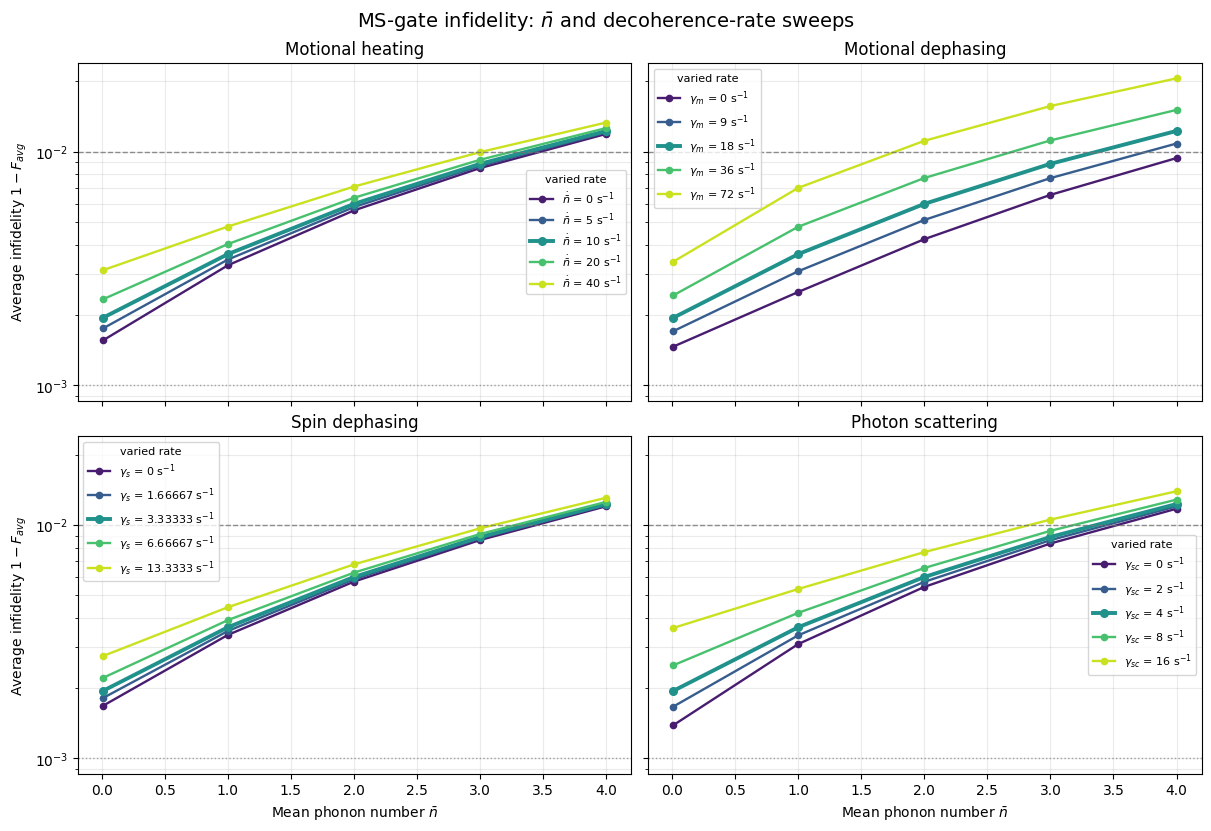

Saved: results/noise_rate_nbar_sweep/infidelity_vs_nbar_by_noise_rate.png


In [5]:
FIGURE_PATH = OUTPUT_DIR / 'infidelity_vs_nbar_by_noise_rate_with_all_noise_zero.png'

def plot_noise_rate_nbar_sweep(summary_table, all_noise_zero_table=None, output_path=None):
    if summary_table.empty:
        print('Nothing to plot. Run or load the QPT sweep first.')
        return None

    fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.2), sharex=True, sharey=True, constrained_layout=True)
    axes = axes.ravel()
    colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(RATE_MULTIPLIERS)))

    for ax, source in zip(axes, NOISE_SOURCES):
        source_table = summary_table[summary_table['noise_source'] == source]
        for color, multiplier, strength in zip(colors, RATE_MULTIPLIERS, RATE_VALUES[source]):
            curve = source_table[np.isclose(source_table['varied_strength_s^-1'], strength)].sort_values('nbar')
            if curve.empty:
                continue
            is_nominal = np.isclose(multiplier, 1.0)
            ax.semilogy(
                curve['nbar'],
                curve['infidelity'],
                marker='o',
                color=color,
                linewidth=2.8 if is_nominal else 1.7,
                markersize=5.5 if is_nominal else 4.5,
                label=legend_label(source, strength),
            )
        if all_noise_zero_table is not None and not all_noise_zero_table.empty:
            zero_curve = all_noise_zero_table.sort_values('nbar')
            ax.semilogy(
                zero_curve['nbar'],
                zero_curve['infidelity'],
                marker='s',
                color='black',
                linestyle='--',
                linewidth=2.2,
                markersize=4.5,
                label='All four noises off',
                zorder=5,
            )
        ax.axhline(1e-2, color='0.45', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.axhline(1e-3, color='0.55', linestyle=':', linewidth=1.0, alpha=0.8)
        ax.set_title(SOURCE_TITLES[source])
        ax.grid(True, which='both', alpha=0.25)
        ax.legend(fontsize=8, title='varied rate', title_fontsize=8)

    for ax in axes[2:]:
        ax.set_xlabel(r'Mean phonon number $\bar{n}$')
    for ax in axes[::2]:
        ax.set_ylabel(r'Average infidelity $1-F_{avg}$')
    fig.suptitle(r'MS-gate infidelity: $\bar{n}$, rate sweeps, and all-noise-zero reference', fontsize=14)

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=220, bbox_inches='tight')
    return fig

figure = plot_noise_rate_nbar_sweep(
    summary,
    all_noise_zero_table=all_noise_zero_summary,
    output_path=FIGURE_PATH if not summary.empty else None,
)
if figure is not None:
    plt.show()
    print('Saved:', FIGURE_PATH)

## 6. Noise sensitivity relative to the nominal-rate curve

同じ $\bar{n}$ における基準レート（1.0x）との Infidelity 差を併記します。正値は、そのレート変化によって Infidelity が基準条件より増えたことを意味します。

In [6]:
if summary.empty:
    sensitivity_summary = pd.DataFrame()
else:
    nominal = (
        summary[np.isclose(summary['multiplier'], 1.0)]
        [['noise_source', 'nbar', 'infidelity']]
        .rename(columns={'infidelity': 'nominal_infidelity'})
    )
    sensitivity_summary = summary.merge(nominal, on=['noise_source', 'nbar'], how='left')
    sensitivity_summary['delta_infidelity_vs_nominal'] = (
        sensitivity_summary['infidelity'] - sensitivity_summary['nominal_infidelity']
    )
    sensitivity_summary.to_csv(OUTPUT_DIR / 'sensitivity_vs_nominal.csv', index=False)

display(sensitivity_summary)

,noise_source,multiplier,varied_strength_s^-1,nbar,F_avg,infidelity,nominal_infidelity,delta_infidelity_vs_nominal
0,motional_dephasing,0.0,0.000000,0.01,0.998536,0.001464,0.001947,-0.000482
1,motional_dephasing,0.0,0.000000,1.00,0.997492,0.002508,0.003644,-0.001136
2,motional_dephasing,0.0,0.000000,2.00,0.995777,0.004223,0.005981,-0.001758
3,motional_dephasing,0.0,0.000000,3.00,0.993463,0.006537,0.008878,-0.002341
4,motional_dephasing,0.0,0.000000,4.00,0.990603,0.009397,0.012281,-0.002884
...,...,...,...,...,...,...,...,...
95,spin_dephasing,4.0,13.333333,0.01,0.997256,0.002744,0.001947,0.000797
96,spin_dephasing,4.0,13.333333,1.00,0.995560,0.004440,0.003644,0.000796
97,spin_dephasing,4.0,13.333333,2.00,0.993226,0.006774,0.005981,0.000793
98,spin_dephasing,4.0,13.333333,3.00,0.990332,0.009668,0.008878,0.000790


## Usage notes

1. まず `EXECUTE_QPT=False` で `SCENARIOS` を確認します。
2. 設定が正しければ `EXECUTE_QPT=True` に変え、ノート全体を実行します。
3. 中断後は `RESUME=True` のまま再実行すると、完了済み条件をスキップします。
4. `NBAR_VALUES`、`RATE_MULTIPLIERS`、または `BASE_PARAMETERS` を変える場合は、新しい `OUTPUT_DIR` を使うのが安全です。
5. 追加参照は `all_noise_zero_summary.csv`、基準条件との比較は `all_noise_zero_vs_nominal.csv` に保存されます。
6. 主な図は `infidelity_vs_nbar_by_noise_rate_with_all_noise_zero.png` です。

## 7. Noise-free diagnostic suite

黒破線（4ノイズをすべてゼロ）に残る誤差を、高次Lamb–Dicke項、Fock状態依存性、XX角ずれ、位相空間closure、数値収束性の5つの観点から切り分けます。計算量が大きく異なるため、以下のフラグを1つずつ `True` にして実行してください。

In [10]:
import noise_free_diagnostics as nfd
nfd = importlib.reload(nfd)

DIAGNOSTIC_OUTPUT_DIR = OUTPUT_DIR / 'noise_free_diagnostics'
ALL_NOISE_ZERO_SUMMARY_PATH = OUTPUT_DIR / 'all_noise_zero_summary.csv'
if (
    'all_noise_zero_summary' not in globals()
    or all_noise_zero_summary.empty
) and ALL_NOISE_ZERO_SUMMARY_PATH.exists():
    all_noise_zero_summary = pd.read_csv(ALL_NOISE_ZERO_SUMMARY_PATH)
    print(f'Loaded all-noise-zero reference from {ALL_NOISE_ZERO_SUMMARY_PATH}.')
elif 'all_noise_zero_summary' not in globals():
    all_noise_zero_summary = pd.DataFrame()
    print('All-noise-zero reference is missing; run section 4 first.')

# 重い解析は1つずつ True にする。既存cacheは False でも読み込まれる。
RUN_FULL_VS_LD_QPT = True
RUN_FOCK_RESOLVED = True
RUN_XX_ANGLE_CORRECTION_QPT = True
RUN_NUMERICAL_CONVERGENCE_QPT = True

FOCK_THERMAL_TAIL_TOLERANCE = 1e-5
FOCK_PHONON_BUFFER = 24
CONVERGENCE_NBAR_VALUES = (0.01, 4.0)
CONVERGENCE_PHONON_DIM_FACTORS = (1.0, 1.25, 1.5)
CONVERGENCE_TIME_POINT_FACTORS = (1.0, 1.5, 2.0)

analysis_budget = pd.DataFrame([
    {'analysis': 'full-order vs LD1', 'master_equation_evolutions': 16 * len(NBAR_VALUES), 'other_evolutions': 0},
    {'analysis': 'Fock-resolved', 'master_equation_evolutions': 0, 'other_evolutions': nfd.fock_analysis.required_fock_cutoff(max(NBAR_VALUES), FOCK_THERMAL_TAIL_TOLERANCE) + 1},
    {'analysis': 'XX correction before/after', 'master_equation_evolutions': 2 * 16 * len(NBAR_VALUES), 'other_evolutions': 0},
    {'analysis': 'phase-space closure', 'master_equation_evolutions': 0, 'other_evolutions': 0},
    {'analysis': 'numerical convergence', 'master_equation_evolutions': 16 * len(CONVERGENCE_NBAR_VALUES) * (len(CONVERGENCE_PHONON_DIM_FACTORS) + len(CONVERGENCE_TIME_POINT_FACTORS)), 'other_evolutions': 0},
])
display(analysis_budget)

Loaded all-noise-zero reference from results/noise_rate_nbar_sweep/all_noise_zero_summary.csv.


,analysis,master_equation_evolutions,other_evolutions
0,full-order vs LD1,80,0
1,Fock-resolved,0,52
2,XX correction before/after,160,0
3,phase-space closure,0,0
4,numerical convergence,192,0


### 7.1 Full-order vs first-order Lamb–Dicke

`use_full_order=True` の黒破線と、同じ無ノイズ条件の一次Lamb–Dicke近似（`use_full_order=False`）をfull QPTで比較します。差 $I_{full}-I_{LD1}$ が高次Lamb–Dicke項に対する直接的な指標です。

MS gate simulation progress: 5 n_bar values x 1 laser samples x 16 input states = 80 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1.0 Simulation Finished (Dim: 25)
n_bar = 2.0 Simulation Finished (Dim: 36)
n_bar = 3.0 Simulation Finished (Dim: 51)
n_bar = 4.0 Simulation Finished (Dim: 67)
--- Result Summary (Error Rate) ---
n_bar = 0.01: Error = 1.733454e-09 (Fidelity = 1.000000)
n_bar = 1.0: Error = 2.392188e-06 (Fidelity = 0.999998)
n_bar = 2.0: Error = 8.139278e-06 (Fidelity = 0.999992)
n_bar = 3.0: Error = 3.573840e-06 (Fidelity = 0.999996)
n_bar = 4.0: Error = 1.825545e-06 (Fidelity = 0.999998)


,nbar,infidelity_full_order,infidelity_lamb_dicke,delta_infidelity_full_minus_ld,higher_order_fraction_of_full
0,0.01,0.000249,1.733454e-09,0.000249,0.999993
1,1.00,0.001302,2.392188e-06,0.001299,0.998163
2,2.00,0.003026,8.139278e-06,0.003018,0.997310
3,3.00,0.005350,3.573840e-06,0.005347,0.999332
4,4.00,0.008221,1.825545e-06,0.008220,0.999778


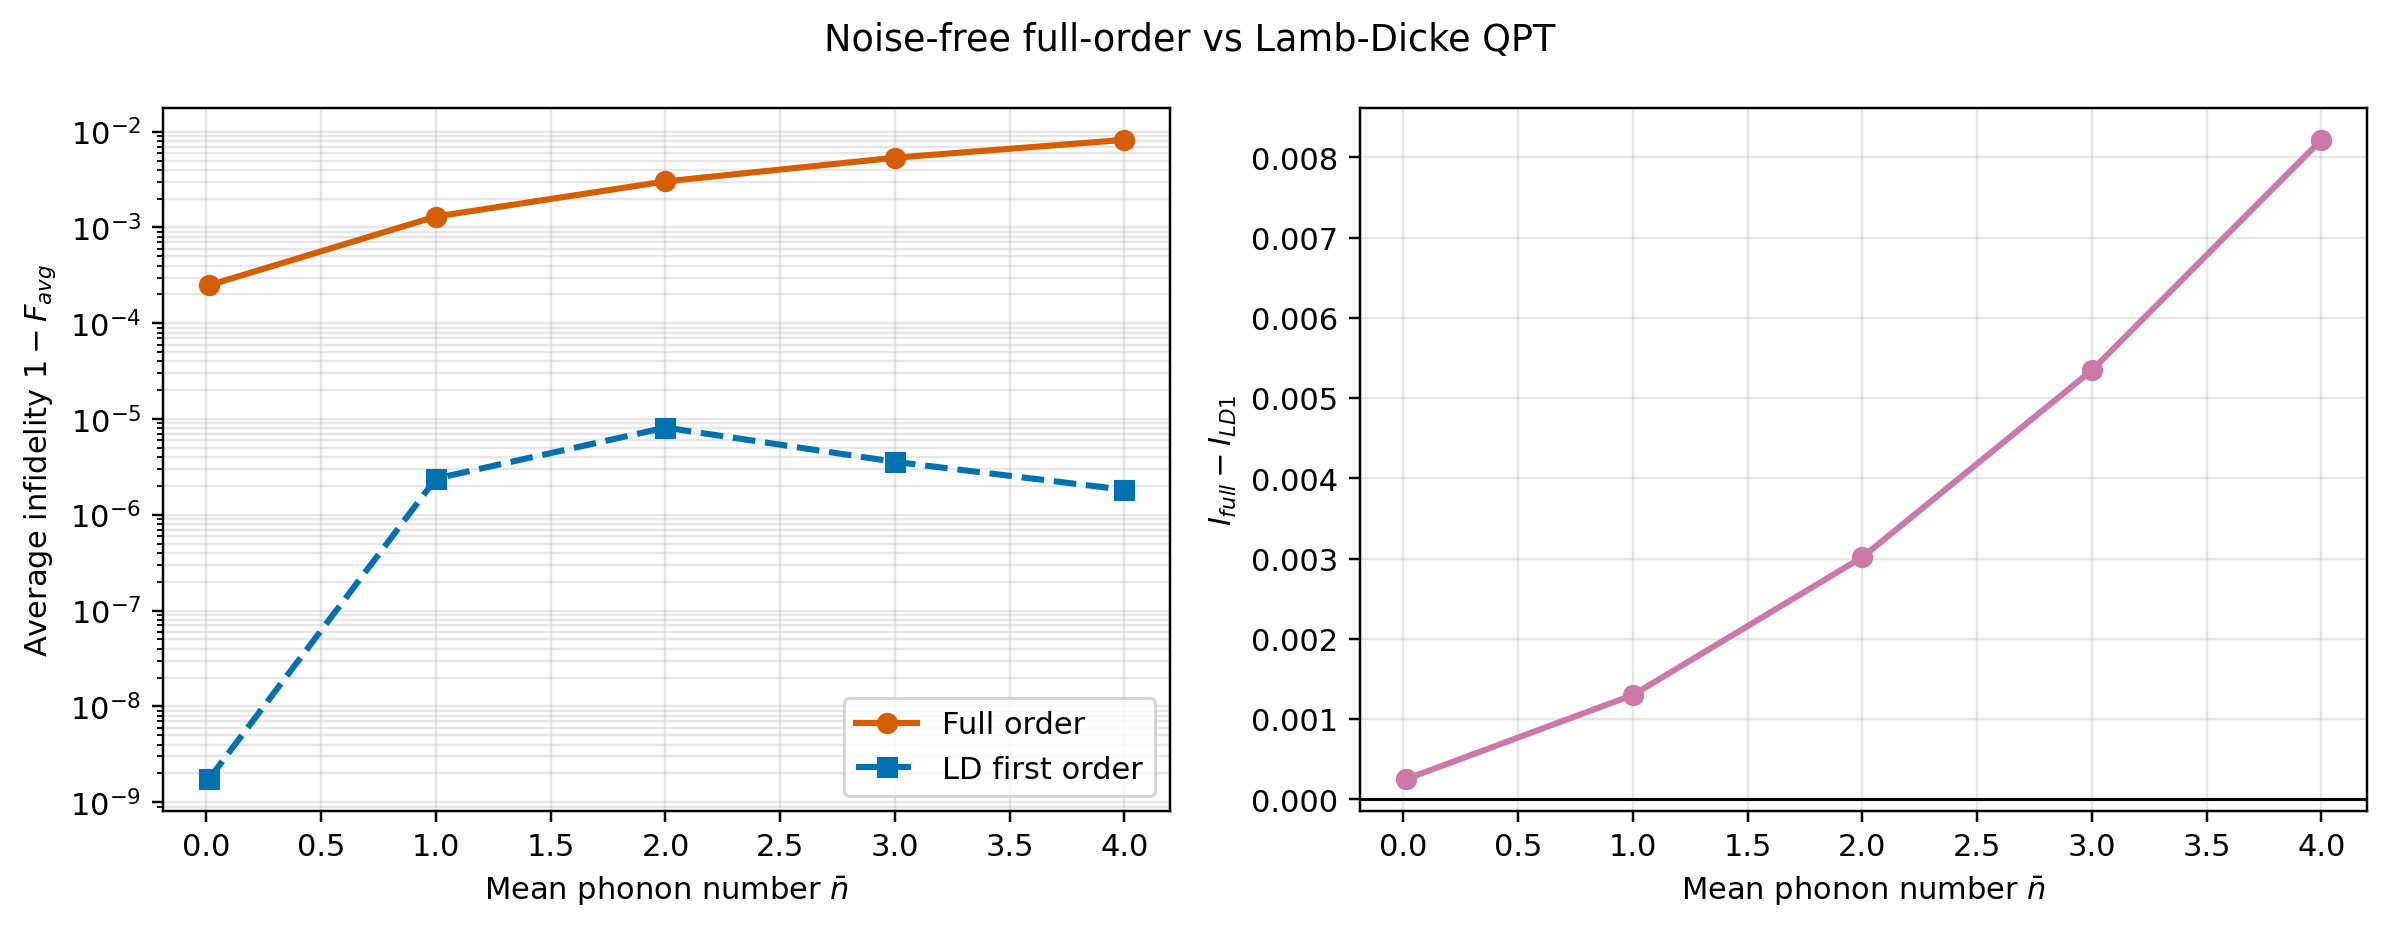

In [11]:
full_vs_ld_result = nfd.run_full_vs_ld_comparison(
    output_dir=DIAGNOSTIC_OUTPUT_DIR / 'full_vs_lamb_dicke',
    base_parameters=BASE_PARAMETERS,
    nbar_values=NBAR_VALUES,
    full_order_summary=all_noise_zero_summary,
    execute=RUN_FULL_VS_LD_QPT,
    resume=RESUME,
)
if full_vs_ld_result['comparison'].empty:
    print('LD1 QPT cache is missing. Set RUN_FULL_VS_LD_QPT=True and rerun this cell.')
else:
    display(full_vs_ld_result['comparison'])
    display(Image(filename=str(full_vs_ld_result['figure_path'])))

### 7.2 Fock-state-resolved analysis

初期Fock状態 $|n\rangle$ ごとに、強制分岐と非強制分岐のcoherence $c_n$ を計算します。$\theta_{XX}(n)=\arg(c_n)/2$ がFock状態ごとのXX角、$1-|c_n|$ が残留spin–motion entanglementの指標です。

Required maximum Fock index: 51


,fock_n,coherence_real,coherence_imag,coherence_abs,theta_xx_rad,theta_error_rad
0,0,0.027160,0.999513,0.999882,0.771815,0.013583
1,1,0.057894,0.997975,0.999653,0.756425,0.028973
2,2,0.088332,0.995524,0.999435,0.741149,0.044249
3,3,0.118450,0.992183,0.999228,0.725988,0.059410
4,4,0.148221,0.987976,0.999032,0.710941,0.074457
5,5,0.177624,0.982927,0.998847,0.696008,0.089390
6,6,0.206635,0.977060,0.998672,0.681190,0.104208
7,7,0.235235,0.970402,0.998506,0.666487,0.118911
8,8,0.263404,0.962976,0.998351,0.651898,0.133500
9,9,0.291124,0.954809,0.998205,0.637424,0.147974


,thermal_n_bar,retained_thermal_mass,thermal_tail_mass,effective_theta_xx_rad,predicted_h_XX_rad_per_gate,theta_xx_linear_mean_rad,theta_xx_variance_rad2,theta_xx_std_rad,mean_forced_null_coherence_abs,gamma_XX_phase_dispersion_per_gate,gamma_XX_with_residual_motion_per_gate,residual_motion_gamma_per_gate
0,0.01,1.000000,0.000000e+00,0.771661,0.013737,0.771661,0.000002,0.001546,0.999875,0.000002,0.000062,0.000060
1,1.00,1.000000,2.220446e-16,0.756559,0.028839,0.756539,0.000460,0.021443,0.998747,0.000459,0.000627,0.000168
2,2.00,1.000000,6.970350e-10,0.741572,0.043826,0.741493,0.001338,0.036583,0.996804,0.001335,0.001601,0.000266
3,3.00,1.000000,3.185559e-07,0.726868,0.058530,0.726675,0.002596,0.050950,0.994141,0.002585,0.002938,0.000353
4,4.00,0.999991,9.134385e-06,0.712461,0.072938,0.712092,0.004192,0.064742,0.990848,0.004166,0.004597,0.000431


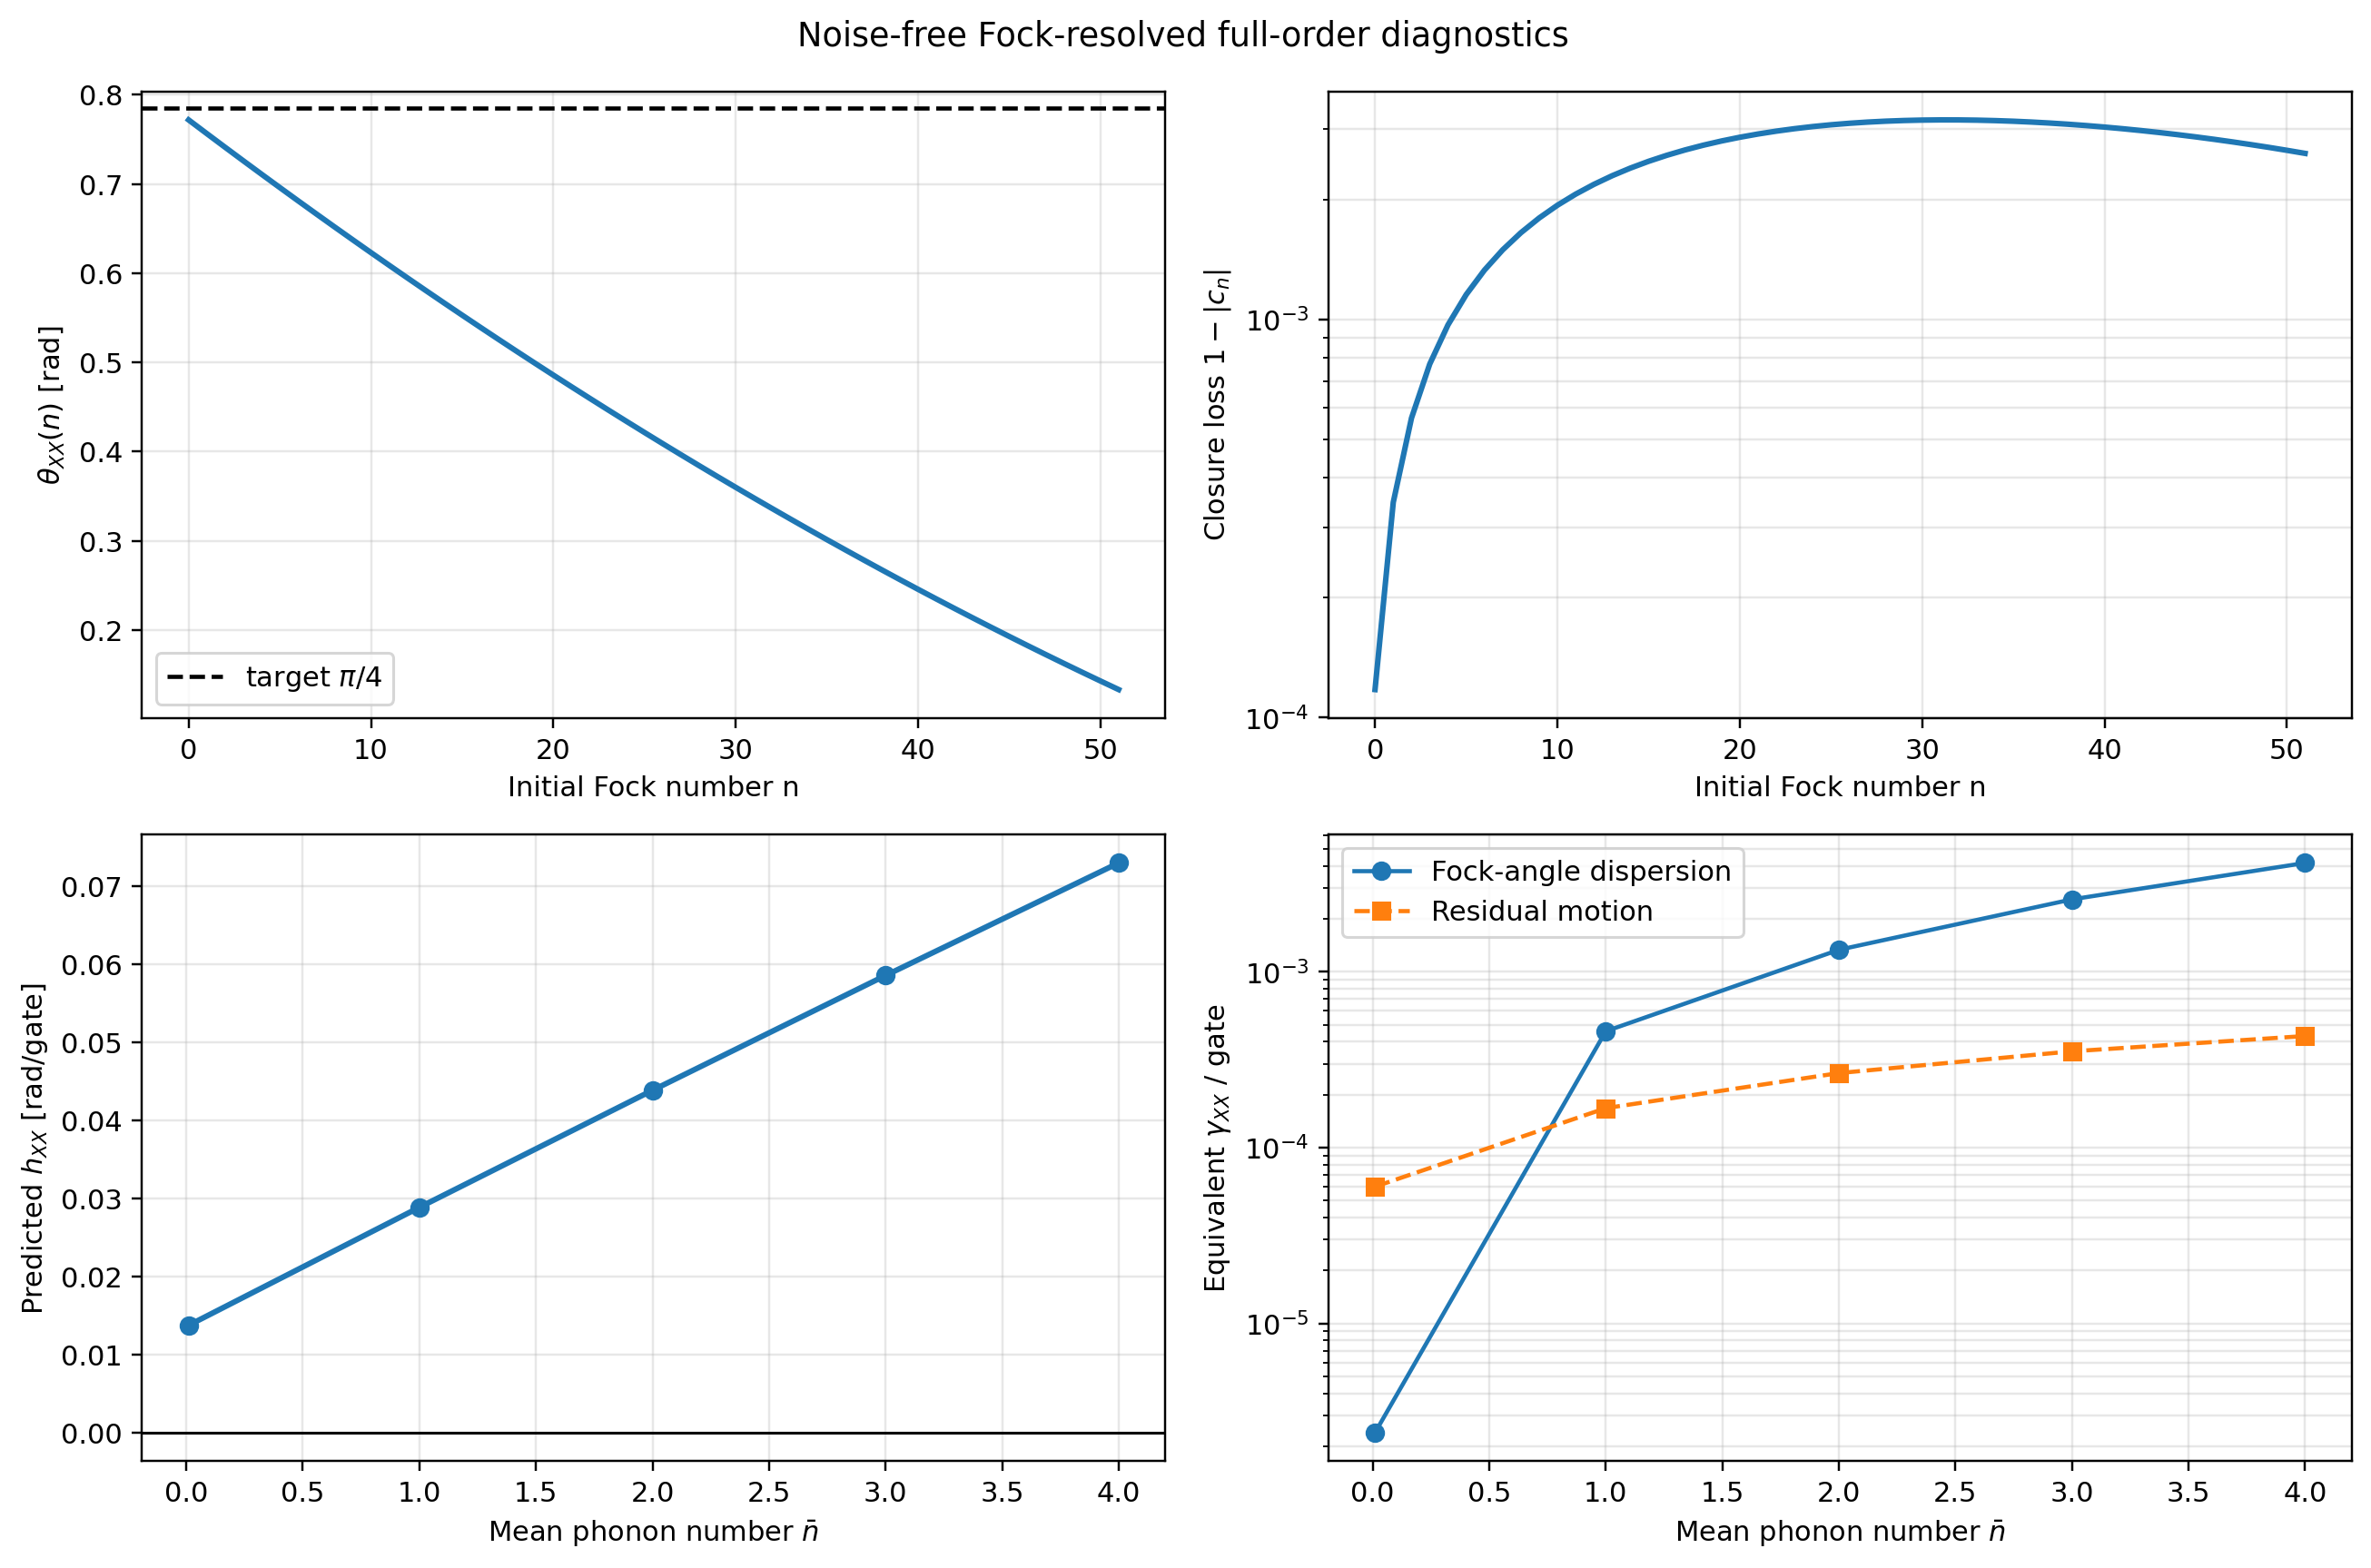

In [12]:
fock_result = nfd.run_fock_resolved_analysis(
    output_dir=DIAGNOSTIC_OUTPUT_DIR / 'fock_resolved',
    base_parameters=BASE_PARAMETERS,
    nbar_values=NBAR_VALUES,
    execute=RUN_FOCK_RESOLVED,
    resume=RESUME,
    thermal_tail_tolerance=FOCK_THERMAL_TAIL_TOLERANCE,
    phonon_buffer=FOCK_PHONON_BUFFER,
)
print(f"Required maximum Fock index: {fock_result['max_fock_n']}")
if fock_result['curve'].empty:
    print('Fock cache is missing. Set RUN_FOCK_RESOLVED=True and rerun this cell.')
else:
    display(fock_result['curve'])
    display(fock_result['thermal_summary'])
    display(Image(filename=str(fock_result['figure_path'])))

### 7.3 Before/after XX-angle correction

無ノイズfull-order QPTから $h_{XX}$ を抽出し、$A_{new}=A\sqrt{(\pi/4)/(\pi/4-h_{XX})}$ の1ステップ補正を行った後に再度full QPTします。補正後にinfidelityが残れば、単純なXX角ずれだけでは説明できない成分です。

MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 1.0 Simulation Finished (Dim: 25)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 1.0 Simulation Finished (Dim: 25)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 2.0 Simulation Finished (Dim: 36)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 2.0 Simulation Finished (Dim: 36)
MS gate simulation progres

,nbar,A_before,A_after,A_factor,h_XX_before_rad_per_gate,h_XX_after_rad_per_gate,theta_XX_before_rad,theta_XX_after_rad,infidelity_before,infidelity_after,infidelity_reduction,gamma_XX_before_per_gate,gamma_XX_after_per_gate
0,0.01,0.125,0.126108,1.008862,0.013737,0.000103,0.771661,0.785296,0.000249,0.000103,0.000146,0.000002,0.000002
1,1.00,0.125,0.127360,1.018881,0.028839,0.000215,0.756559,0.785183,0.001302,0.000697,0.000604,0.000460,0.000495
2,2.00,0.125,0.128641,1.029124,0.043824,0.000320,0.741574,0.785078,0.003026,0.001702,0.001324,0.001336,0.001495
3,3.00,0.125,0.129935,1.039482,0.058529,0.000407,0.726869,0.784991,0.005350,0.003114,0.002237,0.002583,0.003007
4,4.00,0.125,0.131243,1.049943,0.072941,0.000465,0.712457,0.784934,0.008221,0.004938,0.003283,0.004164,0.005040


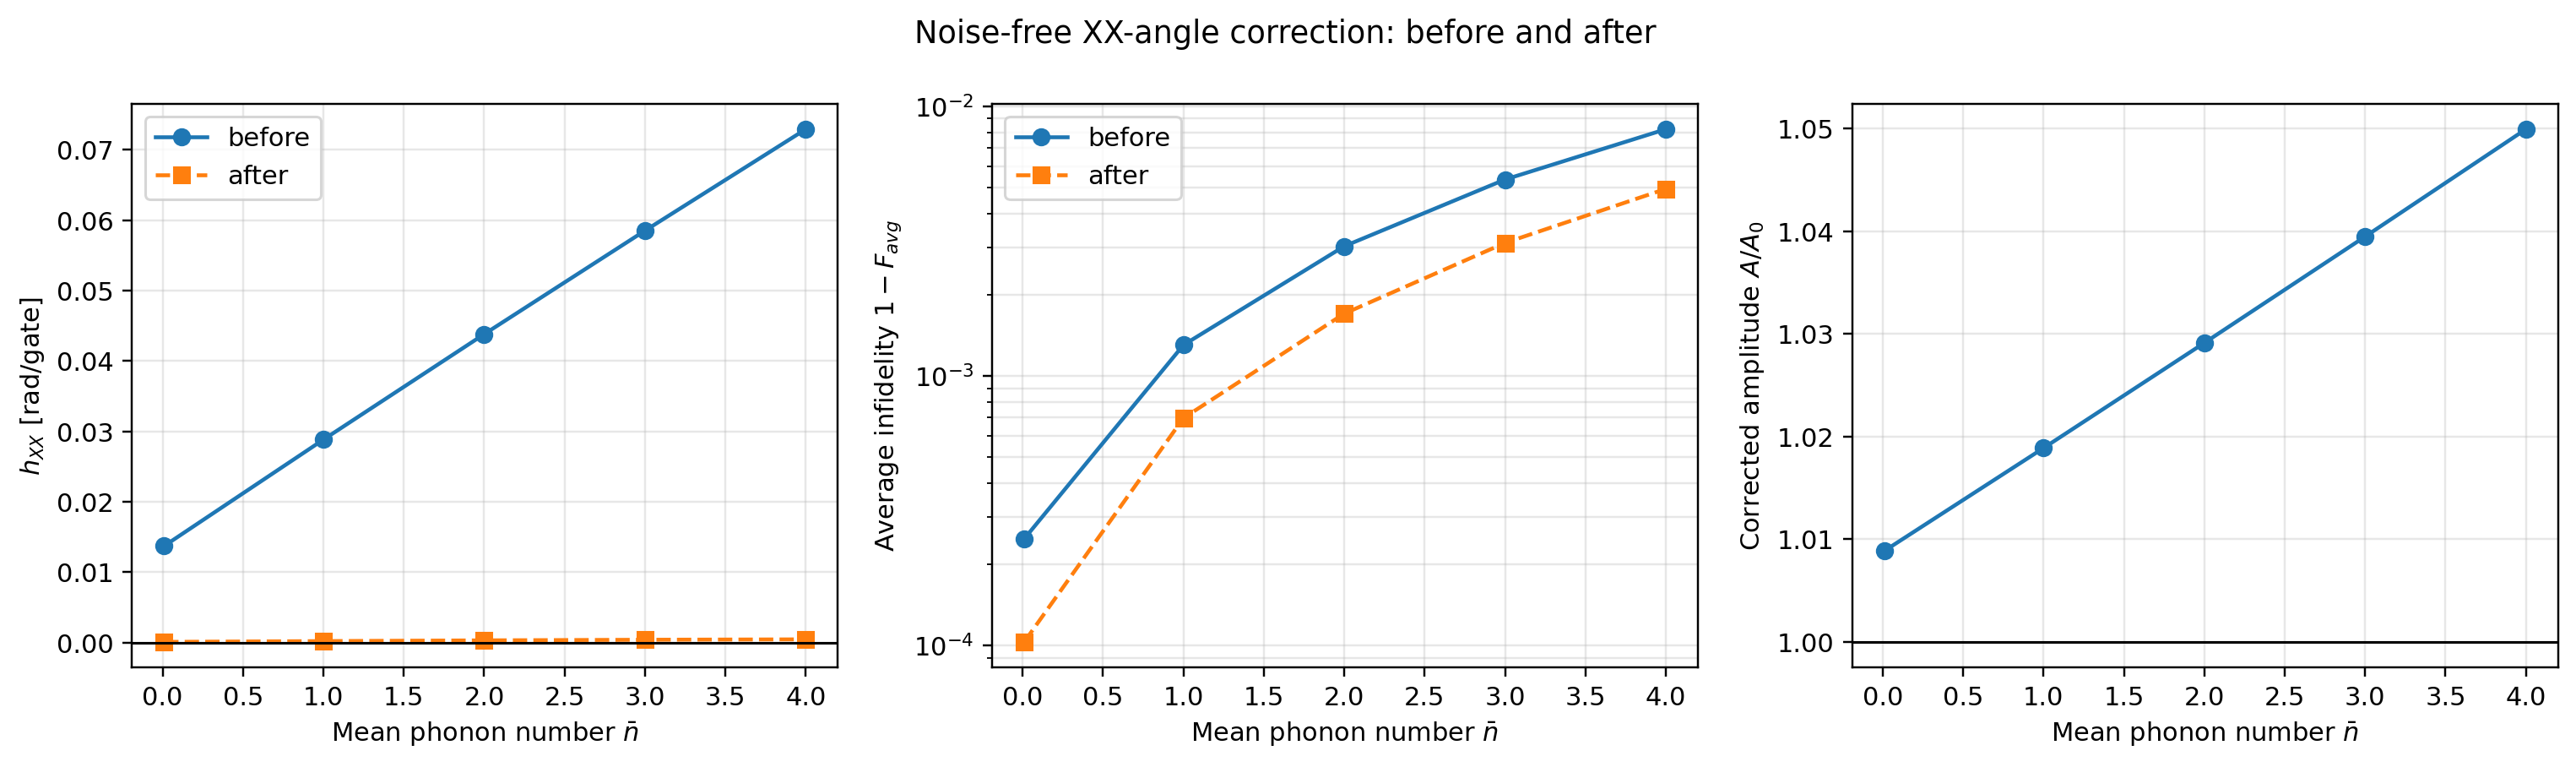

In [13]:
xx_correction_result = nfd.run_xx_angle_correction_comparison(
    output_dir=DIAGNOSTIC_OUTPUT_DIR / 'xx_angle_correction',
    base_parameters=BASE_PARAMETERS,
    nbar_values=NBAR_VALUES,
    execute=RUN_XX_ANGLE_CORRECTION_QPT,
    resume=RESUME,
)
if xx_correction_result['summary'].empty:
    print('XX-correction QPT cache is missing. Set RUN_XX_ANGLE_CORRECTION_QPT=True and rerun this cell.')
    display(xx_correction_result['pending'])
else:
    display(xx_correction_result['summary'])
    display(Image(filename=str(xx_correction_result['figure_path'])))

### 7.4 Phase-space closure

一次Lamb–Dickeモデルの $\alpha(t)$ 軌道と終点 $|\alpha(T)|$、full-orderのFock状態別closure loss、熱平均後の角分散と残留運動成分を並べて表示します。この節は7.2のcacheから作るため、追加のMasterEquation計算はありません。

In [ ]:
closure_result = nfd.build_phase_space_closure_analysis(
    output_dir=DIAGNOSTIC_OUTPUT_DIR / 'phase_space_closure',
    base_parameters=BASE_PARAMETERS,
    fock_curve=fock_result['curve'],
    fock_thermal_summary=fock_result['thermal_summary'],
    all_noise_zero_summary=all_noise_zero_summary,
)
if closure_result['summary'].empty:
    print('Run or load the Fock-resolved analysis in section 7.2 first.')
else:
    display(closure_result['summary'])
    display(Image(filename=str(closure_result['figure_path'])))

### 7.5 Numerical convergence

$\bar n=0.01,4$ でphonon cutoffとtime-grid/max-stepを独立に細かくし、最も厳しい設定とのinfidelity差を計算します。`relative_delta_to_reference` が結論に必要な精度より十分小さいことを確認します。

In [ ]:
convergence_result = nfd.run_numerical_convergence(
    output_dir=DIAGNOSTIC_OUTPUT_DIR / 'numerical_convergence',
    base_parameters=BASE_PARAMETERS,
    nbar_values=CONVERGENCE_NBAR_VALUES,
    execute=RUN_NUMERICAL_CONVERGENCE_QPT,
    resume=RESUME,
    phonon_dim_factors=CONVERGENCE_PHONON_DIM_FACTORS,
    time_point_factors=CONVERGENCE_TIME_POINT_FACTORS,
)
if convergence_result['summary'].empty:
    print('Convergence cache is missing. Set RUN_NUMERICAL_CONVERGENCE_QPT=True and rerun this cell.')
    display(convergence_result['requested_points'])
else:
    display(convergence_result['summary'])
    display(Image(filename=str(convergence_result['figure_path'])))

### Interpretation guide

- `delta_infidelity_full_minus_ld > 0`: 高次Lamb–Dicke項が無ノイズinfidelityを増やしている。
- `theta_xx_rad` のFock依存性: 熱分布によるXX角分散の原因。
- XX補正後も残る `infidelity_after`: 単一のcoherent XX角ずれ以外の成分。
- $|\alpha(T)|\simeq0$ でもfull-order closure lossが増える場合: 一次近似では閉じるが、Fock依存の高次項で閉じない。
- 収束誤差が観測した物理効果と同程度なら、物理的な結論より先にcutoff/time-gridを増やす。